<a href="https://colab.research.google.com/github/almahmud23/Link-of-Drive/blob/Mahmud/Lab_Report_5_212002142.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [2]:
file_path = '/content/Wholesale customers data.csv'
df = pd.read_csv(file_path)

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [6]:
print("\nAlthough All Columns here are int64 types but for better analysis we remove columns 'Channel' & 'Region'")


Although All Columns here are int64 types but for better analysis we remove columns 'Channel' & 'Region'


In [7]:
df_cleaned = df.drop(columns=['Channel', 'Region'], errors='ignore')

In [8]:
df_cleaned.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [10]:
print("\nScaling & Applying DBSCAN. ")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)

dbscan = DBSCAN(eps=1.9, min_samples=4)
clusters = dbscan.fit_predict(scaled_data)


Scaling & Applying DBSCAN. 


In [11]:
print("\nAdd clusters to the DataFrame.")
df['Cluster'] = clusters


Add clusters to the DataFrame.


In [12]:
print(df)

     Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  Cluster  
0          1338        0  
1          1776        0  
2          7844        0  
3          1788

In [13]:
print(df['Cluster'])

0      0
1      0
2      0
3      0
4      0
      ..
435   -1
436    0
437    0
438    0
439    0
Name: Cluster, Length: 440, dtype: int64



 Visualizing the Clusters using PCA.


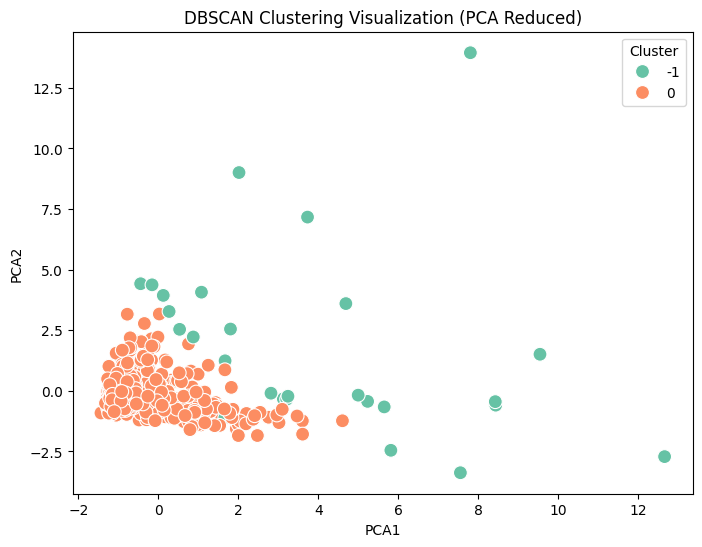

In [14]:
print("\n Visualizing the Clusters using PCA.")

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=100)
plt.title('DBSCAN Clustering Visualization (PCA Reduced)')
plt.legend(title='Cluster')
plt.show()


 Visualizing the Clusters.


<ipython-input-19-fb0ad3e4d478>:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(unique_labels))


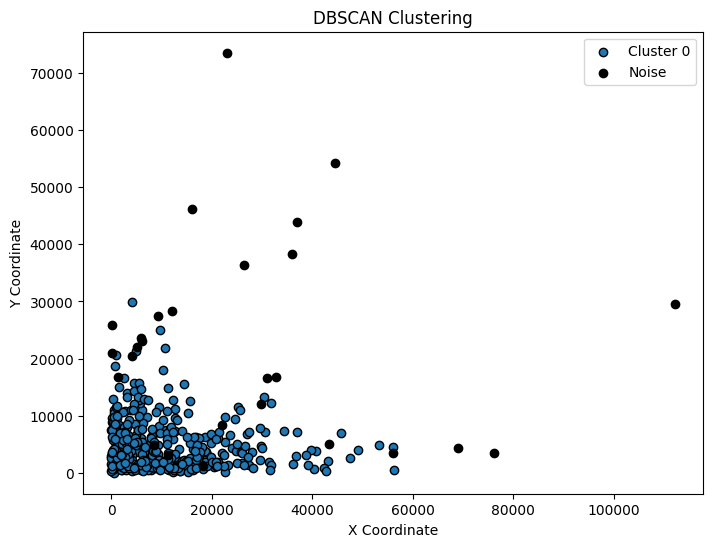

In [19]:
print("\n Visualizing the Clusters.")

plt.figure(figsize=(8, 6))
unique_labels = set(clusters)
colors = plt.cm.get_cmap("tab10", len(unique_labels))

for label in unique_labels:
    if label == -1:
        cluster_points = df_cleaned[clusters == label]
        # Access columns by name using .loc for location-based indexing
        plt.scatter(cluster_points.loc[:, df_cleaned.columns[0]], cluster_points.loc[:, df_cleaned.columns[1]],
                    label='Noise', color='black', edgecolor='k')
    else:
        cluster_points = df_cleaned[clusters == label]
        # Access columns by name using .loc for location-based indexing
        plt.scatter(cluster_points.loc[:, df_cleaned.columns[0]], cluster_points.loc[:, df_cleaned.columns[1]],
                    label=f'Cluster {label}', edgecolor='k')

plt.title("DBSCAN Clustering")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()

In [20]:
print("\nCluster Value Counts:")
print(df['Cluster'].value_counts())


Cluster Value Counts:
Cluster
 0    413
-1     27
Name: count, dtype: int64
